**Loading The Dataset**

The dataset was generated from experiment conducted on PsychoPy. Here we load that dataset to perform our analysis

In [11]:
#Loading Dependencies

import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import skew

#Loading Excel Sheet
df = pd.read_excel("/content/stroop.xlsx", header=1)

**Cleaning the Data**

The Excel file contains Reaction Times recorded for 10 Participants, However it also contains summary statistics for the data, we clean the data to ensure only valid participant data was retained for our test

In [12]:
#Remove non-data columns
df = df.iloc[:, 2:]

#CLEAN DATA
#Convert everything to numeric(invalid → NaN)
df = df.apply(pd.to_numeric, errors='coerce')

#Remove summary rows (mean, SD etc.)
df = df[df.iloc[:, 0].notna()]

#Remove extra rows (keep only first 18 participants)
df = df.iloc[:18]
df = df.drop(index=16)

#Match corresponding columns
english_cols = df.columns[:10]
hindi_cols = df.columns[10:20]

**Calculating Means**

After cleaning the dataset, participant-wise mean reaction times were computed for both English and Hindi conditions. Since each participant completed multiple trials per condition, averaging was performed to obtain a single representative reaction time per participant.

In [13]:
#Means
df["English_Mean"] = df[english_cols].mean(axis=1)
df["Hindi_Mean"] = df[hindi_cols].mean(axis=1)

#Verification
print("\nNumber of participants used:", len(df))

print("\nSample data being used:")
print(df[["English_Mean", "Hindi_Mean"]].head())



Number of participants used: 10

Sample data being used:
   English_Mean  Hindi_Mean
0      4.887254    3.558898
1      3.768929    2.628455
2      3.220052    2.905388
3      3.405591    4.732481
4      3.937691    3.439901


**Descriptive Stats**

We compute means and standard deviation of mean of each participant's reaction time to estimate their central tendencies  

In [14]:
#Descriptive Statistics
print("\nDescriptive Statistics:")
print("English Mean:", df["English_Mean"].mean())
print("Hindi Mean:", df["Hindi_Mean"].mean())
print("English SD:", df["English_Mean"].std())
print("Hindi SD:", df["Hindi_Mean"].std())


Descriptive Statistics:
English Mean: 3.599025954994141
Hindi Mean: 3.4907363090038417
English SD: 0.8455683754011092
Hindi SD: 1.4052376751626607


Although the Hindi condition shows a slightly lower average reaction time, it exhibits substantially greater variability, with a standard deviation nearly twice that of the English condition. This indicates that participant responses in Hindi were less consistent, with a wider spread of reaction times.

**Data Visualization**

To visualize the distribution of reaction times in both conditions, histograms were plotted for the participant-wise mean reaction times. This allows for a comparison of the overall shape, spread, and potential skewness of the data in English and Hindi.

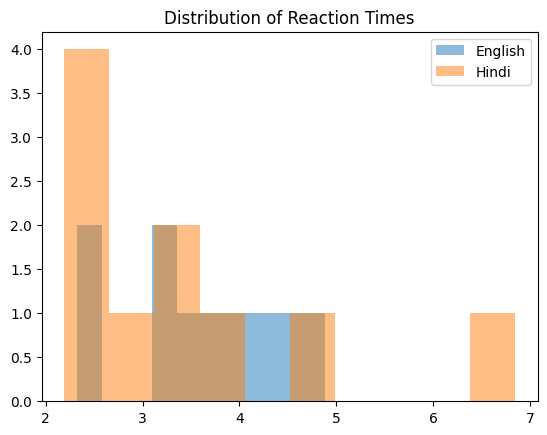

In [15]:

plt.hist(df["English_Mean"], alpha=0.5, label="English")
plt.hist(df["Hindi_Mean"], alpha=0.5, label="Hindi")
plt.legend()
plt.title("Distribution of Reaction Times")
plt.show()

To further compare the distribution of reaction times between the two conditions, a box plot was constructed. This visualization highlights differences in central tendency, spread, and the presence of potential outliers across English and Hindi reaction times.

/tmp/ipykernel_1108/3093374835.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df["English_Mean"], df["Hindi_Mean"]], labels=["English", "Hindi"])


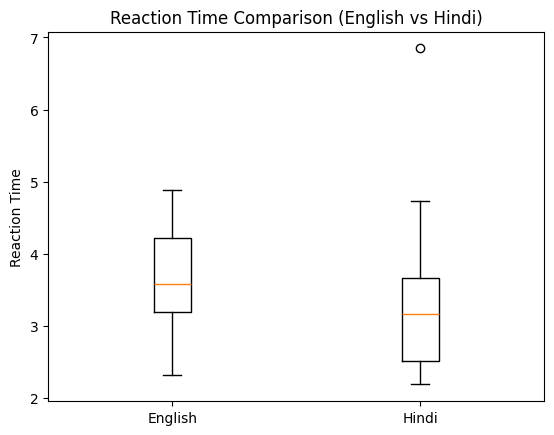

In [16]:
plt.boxplot([df["English_Mean"], df["Hindi_Mean"]], labels=["English", "Hindi"])
plt.ylabel("Reaction Time")
plt.title("Reaction Time Comparison (English vs Hindi)")
plt.show()

The box plot indicates that the Hindi condition has a slightly lower median reaction time compared to the English condition. However, it also exhibits a larger interquartile range, reflecting greater variability in participant responses. This suggests that while some participants responded faster in Hindi, the overall performance was less consistent compared to English.

**Verifying Assumption of Normality**

Before conducting the statistical test, the assumption of normality of paired differences was evaluated. For a paired t-test, it is the distribution of the differences between paired observations that should be approximately normal.

To assess this, a Q-Q plot was generated and skewness of the differences was computed.

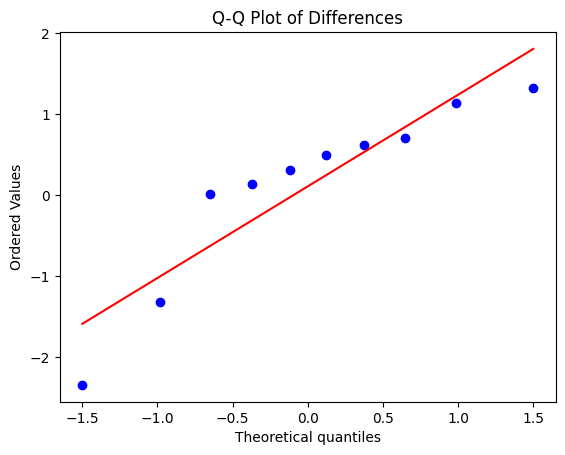

Skew of differences: -1.1747609148941691


In [17]:
diff = df["English_Mean"] - df["Hindi_Mean"]
stats.probplot(diff, dist="norm", plot=plt)
plt.title("Q-Q Plot of Differences")
plt.show()

print("Skew of differences:", skew(diff))

While some skewness is present, the deviation from normality is not substantial enough to invalidate the use of the paired t-test, given its robustness to moderate departures from this assumption.

**Statsistical Tests**

To determine whether there is a statistically significant difference in reaction times between the two conditions, a paired t-test was conducted.

Since the same participants were measured under both English and Hindi conditions, a paired test is appropriate as it accounts for within-subject variability. In addition to the overall comparison based on mean reaction times, trial-wise paired t-tests were also performed to examine differences at the level of individual trials.

In [18]:
#Paired T test
t_stat, p_val = stats.ttest_rel(
    df["English_Mean"],
    df["Hindi_Mean"],
    nan_policy='omit'
)

print("\nPaired Sample T-Test (Overall):")
print("t =", t_stat)
print("p =", p_val)

if p_val < 0.05:
    print("Significant difference between English and Hindi")
else:
    print("No significant difference")

#Trial Wise Paired T-Test
print("\nTrial-wise Paired T-tests:")

for i in range(10):
    eng = df.iloc[:, i]
    hin = df.iloc[:, i+10]

    t, p = stats.ttest_rel(eng, hin, nan_policy='omit')
    print(f"Pair {i+1}: t = {round(t,3)}, p = {round(p,3)}")




Paired Sample T-Test (Overall):
t = 0.30346738470258994
p = 0.7684318436179353
No significant difference

Trial-wise Paired T-tests:
Pair 1: t = 0.633, p = 0.542
Pair 2: t = 1.394, p = 0.197
Pair 3: t = -0.461, p = 0.656
Pair 4: t = 2.009, p = 0.075
Pair 5: t = -1.347, p = 0.211
Pair 6: t = -2.026, p = 0.073
Pair 7: t = -0.023, p = 0.982
Pair 8: t = -0.814, p = 0.437
Pair 9: t = -0.373, p = 0.718
Pair 10: t = 3.074, p = 0.013


The paired sample paired t-test indicated that there was no statistically significant difference in mean reaction times between the English and Hindi conditions (t = 0.30, p = 0.768).

This suggests that any observed difference in average reaction times is likely due to random variation rather than a systematic effect of language.

Trial-wise paired t-tests were also conducted to examine differences at the level of individual trials. Most trials did not show statistically significant differences (p > 0.05). Although one trial (Pair 10) showed a significant result (p = 0.013), this isolated finding is likely due to random variation, especially in the context of multiple comparisons.